                                                 XGB Classifier Higher order indices 

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#  Load Data 
df = pd.read_csv(r"C:\Users\PIYUSH\Downloads\StarGalaxyQuaser1_TwinkleKashyap.csv")


df.drop('objid', axis=1, inplace=True)

In [3]:
#Feature Engineering 

# Basic color indices
df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
df['i_z'] = df['i'] - df['z']

#  Higher-order color indices 
df['u_r'] = df['u'] - df['r']
df['g_i'] = df['g'] - df['i']
df['r_z'] = df['r'] - df['z']

# Data Cleaning 
df = df[(df['u_g'] > -5) & (df['u_g'] < 5) &
        (df['g_r'] > -5) & (df['g_r'] < 5)]


In [4]:
# Encode Labels 
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

#  Features & Target 
X = df.drop('class', axis=1)
y = df['class']

feature_names = X.columns

In [5]:
# Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [6]:
#  XGBoost Model 
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [7]:
#  Predictions 
y_pred = xgb.predict(X_test)

In [8]:
#  Evaluation 
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.993765375930981

Confusion Matrix:
[[17518    35    25]
 [  122  2644     0]
 [    3     0  9326]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     17578
           1       0.99      0.96      0.97      2766
           2       1.00      1.00      1.00      9329

    accuracy                           0.99     29673
   macro avg       0.99      0.98      0.99     29673
weighted avg       0.99      0.99      0.99     29673



In [9]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',linewidths=0.5, linecolor='black')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

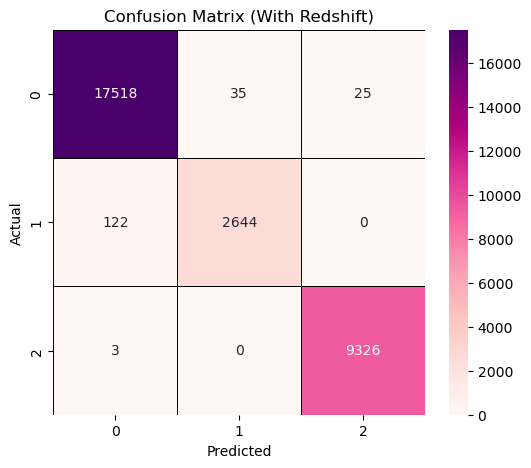

In [10]:
plot_conf_matrix(y_test, y_pred, "Confusion Matrix (With Redshift)")

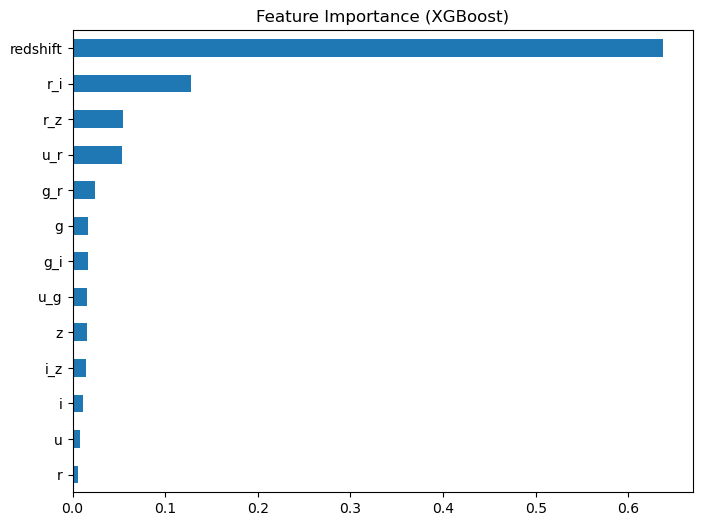

In [11]:
import seaborn as sns

feat_imp = pd.Series(xgb.feature_importances_, index=feature_names)
feat_imp = feat_imp.sort_values()

plt.figure(figsize=(8,6))
feat_imp.plot(kind='barh')
plt.title("Feature Importance (XGBoost)")
plt.show()

In [12]:
import joblib

In [13]:
joblib.dump(xgb, "xgb_with_redshift.pkl")
joblib.dump(X_train.columns, "features_with_z.pkl")

['features_with_z.pkl']

                                                             Without Redshift 

In [14]:

if 'redshift' in X.columns:
    X = X.drop('redshift', axis=1)


In [15]:
feature_names = list(feature_names)
feature_names.remove('redshift')

In [16]:
#  Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [17]:

#  XGBoost Model 
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [18]:
#  Predictions 
y_pred = xgb.predict(X_test)


In [19]:
#  Evaluation 
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9337444815151822

Confusion Matrix:
[[17137    91   350]
 [  147  2269   350]
 [  755   273  8301]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     17578
           1       0.86      0.82      0.84      2766
           2       0.92      0.89      0.91      9329

    accuracy                           0.93     29673
   macro avg       0.91      0.90      0.90     29673
weighted avg       0.93      0.93      0.93     29673



In [20]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd',linewidths=0.5, linecolor='black')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

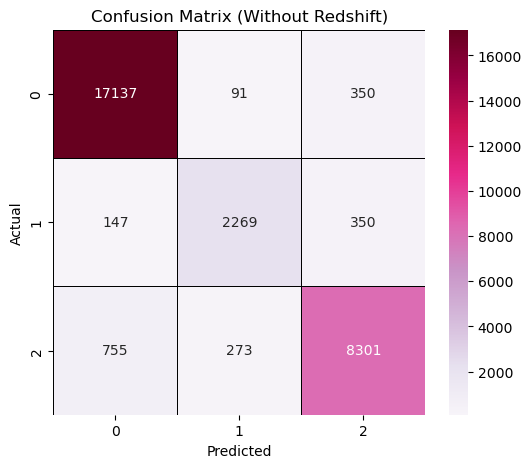

In [21]:
plot_conf_matrix(y_test, y_pred, "Confusion Matrix (Without Redshift)")

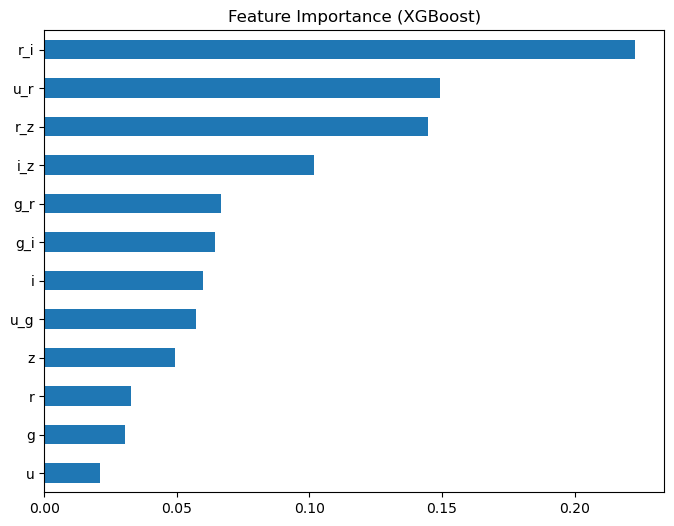

In [22]:
feat_imp = pd.Series(xgb.feature_importances_, index=feature_names)
feat_imp = feat_imp.sort_values()

plt.figure(figsize=(8,6))
feat_imp.plot(kind='barh')
plt.title("Feature Importance (XGBoost)")
plt.show()

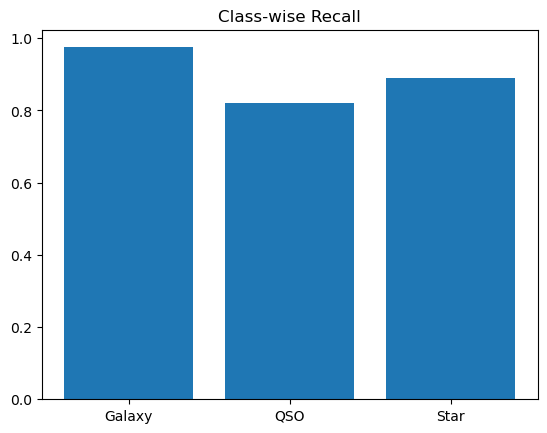

In [23]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True)

recalls = [report[str(i)]['recall'] for i in range(3)]

plt.bar(['Galaxy','QSO','Star'], recalls)
plt.title("Class-wise Recall")
plt.show()

In [24]:
joblib.dump(xgb, "xgb_no_redshift.pkl")
joblib.dump(X_train.columns, "features_no_z.pkl")

['features_no_z.pkl']